[Back to Home](./index.html)

# Setup up an SoS multi-language Jupyter Notebook (including python,C++,and C#:
---
D.S. Leonard, Copyright 2024  All rights reserved.   
(Use the information, quote the document, but the document as a work is mine.  Code is mostly trivial, otherwise MIT).

I cover set up and use of multiple kernels(programming languages) in a Jupyter notebook, including C# (with html-exportable interactive plots) in particular, and particularly using SoS as the kernel switcher.

SoS is a top level "kernel" for jupyter that allows support for most general purpose programming and scripting languages in Jupyter (even bash). Technically the default ipykernel can do similar (and we'll use both methods) but it can be harder to install custom kernels with it.

Jupyter Lab itself can now also configure cells for individual kernels(programming languages) directly within the UI.  I didn't know that when I started this (was using classic Jupyter then), but SoS does have some advantages.  Particularly, it can work in other notebook editors such as vs code, and it can transport results between cells of different languages for what it's worth.  Regardless of the method, at minimum, installation of the various kernels is needed.

This guide works through a setup with pyroot for both python and C++,  bash, C# (with plotting), multi-lingual code highlighting, and extra C++ kernels (optional) if desired.

There's a chance when starting from scratch, that this guide won't be QUITE exact, but I think it's close.

## First, Examples of the multilanguage support in action from various languages:
----

In [1]:
%use bash
# Switch to Bash kernel for this cell

echo "Hello World from bash!"


Hello World from bash!



In [2]:
%use python3  
# Switch to Python kernel for this cell

print("Hello World from python")


Hello World from python


In [3]:
%use .net-csharp
using System.IO;
Console.WriteLine("Hello World from C#");


The below script needs to be able to find the current output cell; this is an easy method to get it.

Hello World from C#


### Let's have a little more fun...

#### This is the best language ever, really:

See https://gitlab.com/douglas.s.leonard/UAO2_PLTLY/-/blob/master/UAO2_PLTLY/Program.cs?ref_type=heads
for a much better example with formatting, latex, etc...  (

In [4]:
%use .net-csharp
#r "nuget: Plotly.NET"
#r "nuget: Plotly.NET.Interactive"
#r "nuget: Plotly.NET.ImageExport"
using Microsoft.DotNet.Interactive.Formatting;
using System;
using Plotly.NET;
using Plotly.NET.LayoutObjects;
using Plotly.NET.Interactive;
using System.IO;

double[] xs = { 1, 2, 3, 4, 5 }; 
    double[] ys = { 5, 4, 2, 1, 4 }; 

var plt = Chart2D.Chart.Line<double, double, string>( // <-- Plotly.Net itself is F#, making the argument template here a bit verbose.                                                    
    xs, ys,
    Name: "Sample Plot",
    MarkerSymbol: StyleParam.MarkerSymbol.Circle
);


var layout = Layout.init<IConvertible>();
layout.SetValue("title", "Hello World From C#");
plt.WithLayout(layout);

return plt;


Installed Packages Plotly.NET, 5.1.0 Plotly.NET.ImageExport, 6.1.0 Plotly.NET.Interactive, 5.0.0

Loading extensions from `/home/osboxes/.nuget/packages/plotly.net.interactive/5.0.0/lib/netstandard2.1/Plotly.NET.Interactive.dll`

<!-- Plotly chart will be drawn inside this DIV -->

<span style="color:red">    Note, the plot above is interactive, even in html export, click for data and zoom </span>   
**PyROOT is still here though! :**

Welcome to JupyROOT 6.30/04


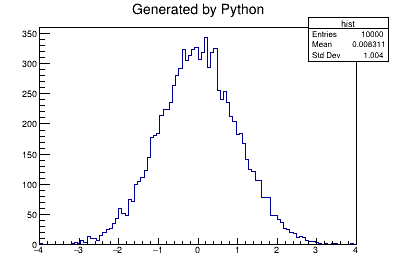

In [5]:
%use python3
import ROOT

hist = ROOT.TH1F("hist", "Generated by Python", 100, -4, 4)
hist.FillRandom("gaus", 10000)

canvas = ROOT.TCanvas("canvas", "Simple Histogram", 400, 300)

hist.Draw()

# Show canvas in Jupyter
canvas.Update()
canvas.Draw()


<span style="color:red">We can generate plots in C++ too AND still access the python ones:</span> 

In [6]:
%use python3
import ROOT 
# redundant, but just in case,for the cell below...

The built in CPP kernel needs access THROUGH the standard python kernel now:

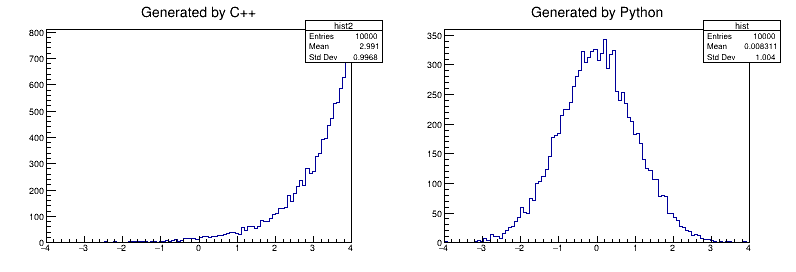

In [7]:
%use python3
%%cpp
#pragma cling add_include_path("/opt/root/root-6.30.04/bindings/pyroot_legacy/src/")
#include <TCanvas.h>
#include <TH1F.h>
#include <PyROOT.h>

void plot_example() {
    TH1F* hist = new TH1F("hist2", "Generated by C++", 100, -4, 4);
    hist->FillRandom("expo", 10000);

    TCanvas* canvas = new TCanvas("canvas2", "Simple Histogram", 800, 300);
    canvas->Divide(2, 1);
    canvas->cd(1);
    hist->Draw();
    canvas->cd(2); 

// WE STILL HAVE THE PYTHON OBJECT!!
    TH1* py_hist = (TH1*)gDirectory->Get("hist");
    py_hist->Draw();
    canvas->Update();  
    canvas->Show();
}

plot_example();


In [8]:
%use xcpp17   
// Switch to C++17 kernel for this cell
// This cell will generate an error about CIFactory the first time, but works and dissappears the second time. 
// It's an old but documented issue in xeus-cling.
#include <iostream>
using namespace std;
cout << "Hello World from xeus-cling++"



ERROR in cling::CIFactory::createCI(): cannot extract standard library include paths!
Invoking:
  LC_ALL=C x86_64-conda-linux-gnu-c++  -O3 -DNDEBUG -xc++ -E -v /dev/null 2>&1 | sed -n -e '/^.include/,${' -e '/^ \/.*++/p' -e '}'
Results was:
With exit code 0
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220628'
  Extraction of runtime standard library version was: '20240904'


Hello World from xeus-cling++

@0x747b1d5fcd20

# Installation and setup:
---
## Prerequisites: (Important, don't skip)

For ROOT work, you'll of course need ROOT installed, with python support.  
You need some version of conda installed already.

You'll need a working conda user env if you don't have one:  
  
<span style="color:red">To work with an existing root installation, you must make your conda python version match the python version that root was installed with</span>  

Check that pyroot is working by running  
```bash
python3
```
and then enter
```bash
import ROOT
```
at the prompt.  If nothing happens, it worked. (great feedback).  
exit (cntrl-D) and do
```bash
python --version
```
then create a new conda environment  
```bash
conda create -n "jupyter" python=<your-python-version>
conda activate jupyter
```
where your-python-version matches the one we just found.   

You can name the env whatever you want.  You can use a later python version, but if you want root to work, you'll have to (successfully) install it with that version.

## (Optional, but highly recommended) Installing mamba
First install mamba to make conda installs MUCH faster.  I'd do this system wide in a base env if possible
but it should be possible as a user too (still in base though if possible).

```bash
## prioritize 'conda-forge' channel
conda config --add channels conda-forge  

## update existing packages to use 'conda-forge' channel
conda update -n base --all  

## install 'mamba'
conda install -n base mamba --yes 

## configure mamba as default conda solver:
conda config --set solver libmamba
##(alternatively type mamba instead of conda)
```
 

## Install Jupyter Lab 
(also optional really as you can use VScode, etc.  I guess everything is optional!)
---

As your user, in your new env:
```bash
mamba install jupyterlab notebook --yes
mamba install  nodejs --yes  # needed for extensions, like highlighting.
```
_Note on installing as root:_  
It seems very difficult to install jupyter globally or even across multiple conda envs.  
Just have to launch it from this one always or install it in others.  Multiple installs 
shouldn't use extra space unless you change versions.


## Installing SoS and subkernels

SoS is a master "kernel" (code interpretter) that handles subkernels for different languages.  
More installation and usage information is available here:  
https://vatlab.github.io/sos-docs/running.html#content 
and here:  
https://vatlab.github.io/sos-docs/doc/user_guide/multi_kernel_notebook.html  

Again, easiest to install this in your user env: 
```bash
#these can be installed with pip instead but again, I use mamba in base env
mamba install sos --yes
mamba install sos-notebook --yes
#optionally add extra sos-kernels:
mamba install sos-bash --yes  # fancy calypso-bash advanced bash kernel
#optionally add papermill integrations (automation and parameterization tools)
mamba install sos-papermill --yes
#...
```

And to export kernels to all envs: 
```bash
python -m sos_notebook.install 
```
If installing as root the, --sys-prefix option may help.  
If attempting an isntall as root, your user may also need to log back in to see changes.

Verify in your user's env
```bash
jupyter kernelspec list

```
You should see sos.  Calypso_bash is less important.

## Adding a basic bash kernel (optional)

As as user in your working conda env:
```
pip install bash_kernel
python -m bash_kernel.install 
```

## Installing .NET 

**Note: 9.0 is the latest since Nov 2024, but as of Jan 2025, the interactive jupyter kernel support for 9.0 is on git, but not in a tagged release yet.  You live in the future though, so check here:**  

https://github.com/dotnet/interactive/releases  

If there is a version greater than 1.0.5530010, it almost certainly means support for 9.0 is released.  Otherwise, stick to 8.0 unless you want to install from git. I did, but steps are far from obvious or well documented.

Dotnet is available for just about any linux and is distributed in several ways depending on linux flavor and version.  In general MS has documented this all well here:  [Link](https://learn.microsoft.com/en-us/dotnet/core/install/linux)

The most universal managed-installation method is likely through snap:[Link](https://learn.microsoft.com/en-us/dotnet/core/install/linux#snap)  

But I prefer tighter apt integraion in ubuntu. The following tables lists the dotnet versions available for different Ubuntu versions via different feeds: [Link](https://learn.microsoft.com/en-us/dotnet/core/install/linux-ubuntu#supported-distributions)  (I think 9.0 is in the feed for Ubuntu 20.04 actually).

Follow the links for the feed there, but for Ubuntu 24.04 for dotnet 9 I do:
```
sudo add-apt-repository ppa:dotnet/backports
```
(**Secret tip:** use sudo -i once, to become root for a whole terminal session (no more sudo)! **BE CAREFUL.**  You didn't hear it from me. Us old-timers used to just login as root back in the wild west days.)  

This has to be a system wide install since its through apt
```bash
sudo apt-get install -y dotnet-sdk-9.0  
```
For what it's worth, you can install multiple dotnet versions system wide and the user can select one by adding this:
```
{
  "sdk": {
    "version": "9.0.101"
  }
}
```
to the file stealthily named as ~/global.json  

## Installing .NET interactive kernel (for C#)

This should be run as a user, probably from conda base env workds best (conda activate base).
```bash
dotnet tool install --global Microsoft.dotnet-interactive  # the kernel
dotnet interactive jupyter install
```
(Note conda activate 

## Multilingual code highlighting (and probably other goodies)

You can install the jupyterlab-sos extension **from the extension manager in jupiter lab itself**.
Just search on SoS and you'll find.  Refresh the browser, and you'll have highlighting.

**Alternative, possibly broken method!:**  
```bash
jupyter labextension install jupyterlab-sos
```
This didn't work for me because of version mistmatch.
This may require restart jupyter or at least the kernel.


## (Very Optional) Installing a standalone C++ kernel (xeus-cling) with pip

Python, with a ROOT setup gives you the cling that came with your ROOT. 
But you can optionally get a stadalone cling kernel.  This is good if you aren't worried about ROOT but just want to run code snippets in a diferent c++ standard (C++11/14/17/20).  It also can give you a cpp interface if you want to install jupyter in another env with a different python version that your root installation wasn't built on.


You can just do:  (but read ahead)
```bash
pip install xeus-cling
```
in your working env. 

The official instructons say to create a special env for it
which is also fine.  Either way you may want or need to do the kernel install steps
below so that you can have them in other envs too later if needed, and then following this whole approach
is a good way to check that anyway:

```bash
conda create -n "cling" python=3.12.8  # or whatever version
conda activate cling
jupyter kernelspec install ~/.conda/envs/cling/share/jupyter/kernels/xcpp11 --sys-prefix
jupyter kernelspec install ~/.conda/envs/cling/share/jupyter/kernels/xcpp14 --sys-prefix
jupyter kernelspec install ~/.conda/envs/cling/share/jupyter/kernels/xcpp17 --sys-prefix

conda activate <your-working-env>
jupyter kernelspec list  # to see if it worked
```
The jupyter kernelspec install will make a kernel installation available across all envs.

## Using JupyterLab with SoS
(Or any Jupyter Notebook really, including VS code)
---

And then run it all:
```
jupyter lab
```

Make a new notebook.  Select the SoS kernel (In JL, upper right, near hamburger, or Kernel->Change Kernel menu tab, similar in VS Code)  

Then in cells use
```
%use <kernelname>
```
to switch lanaguages.    
**the %use statement MUST be the first line and the kernel name must be spelled right**  
This setting should (I think) hold until another cell (that your run) changes it.

To get behavior you are used to you want to use
```
%use python3
```
Once in python3 you can do things you're used to like
```
import ROOT
```
and then in another cell you can start with
```
%%cpp
```
to get your root cling interpretter with root paths setup.
You stack magic commands on the first line:
```
%use python3
%%cpp
```
but you **CANNOT** have code between them:
```
%use python3
import ROOT
%%cpp
```
So you'll two cells to accomplish that.


However now you can do more.  You can switch to bash:
```
%use bash
```
or
```
%use .net-csharp
```
or even
```
%use xcpp17
```
if you installed the xeus-cling kernel.
Note that %%cpp is python kernel magic and work while outside of the python kernel.  You need to restart the python kernel with
```
%use python3
```
At any time you can set the entire notebook back to the ipykernel and have things like normal, but kernel %use switching wont work then.  The standard ipykernel %%cpp will. 


Sos has many features that I don't know including transferring variables between cells and more.  See the links above for more details.

## Troubleshooting

With some conflicting installs I would sometimes get errors with conda, pip or jupyter about write permissions to the system conda install path.
I solved it with this:
```bash
unset JUPYTER_PATH
unset PYTHONPATH
unset JUPYTER_CONFIG_DIR
```
and added it to my .bashrc.  This seems harmless as they correct paths are found anyway.

More here:
https://vatlab.github.io/sos-docs/doc/user_guide/multi_kernel_notebook.html


if you get a cryptic one line error about pkg_resources or something, check the kernel name spelling matches that from the kernelspec list.